In [11]:
import pandas as pd
import numpy as np

df23 = pd.read_csv("model_df_2023.csv")
df24 = pd.read_csv("model_df_2024.csv")
df25 = pd.read_csv("model_df_2025.csv")

df = pd.concat([df23, df24, df25], axis=0, ignore_index=True)

print(df.shape)
print(df.head())
print(df.columns.tolist())

(2114, 70)
    game_id            game_date  season  home_team_code  away_team_code  \
0  20230711  2023-03-23 04:00:00    2023           10001            1001   
1  20230712  2023-03-23 04:00:00    2023           12001            5002   
2  20230716  2023-03-24 04:00:00    2023           10001            1001   
3  20230717  2023-03-24 04:00:00    2023           12001            5002   
4  20230718  2023-03-24 04:00:00    2023            7002            6002   

   stadium_code  home_sp_id  away_sp_id home_sp_name away_sp_name  ...  \
0          1003       14674       11404          김동혁          장필준  ...   
1          2002       11318       14780          엄상백          강효종  ...   
2          1003       11379       14613          최원태          허윤동  ...   
3          2002       15542       13102           슐서          김영준  ...   
4          4001       10610       13061          장민재           곽빈  ...   

   top5_OPS_diff  top5_OBP_diff  sp_ERA_diff  sp_FIP_diff sp_WHIP_diff  \
0       0.015

In [12]:
# 타깃만 따로 보관
y = df["y_home_win"].copy()

# leakage 컬럼 제거
leakage_cols = [
    "home_score",
    "away_score",
    "home_win",
    "game_state"
]

X = df.drop(columns=leakage_cols, errors="ignore")

print("남은 컬럼 수:", len(X.columns))

남은 컬럼 수: 66


In [13]:
duplicate_or_unneeded_cols = [
    "home_sp_id",
    "away_sp_id",
    "home_sp_name",
    "away_sp_name",
    "home_sp_player_name",
    "away_sp_player_name"
]

X = X.drop(columns=duplicate_or_unneeded_cols, errors="ignore")

print("정리 후 컬럼 수:", len(X.columns))

정리 후 컬럼 수: 60


In [14]:
# game_id 중복 개수 확인
dup_counts = X["game_id"].value_counts()
dup_game_ids = dup_counts[dup_counts > 1].index.tolist()

print("중복 game_id 개수:", len(dup_game_ids))
print("예시:", dup_game_ids[:10])

중복 game_id 개수: 0
예시: []


In [20]:
import pandas as pd
import numpy as np

# -----------------------------
# 1) game_id가 경기당 1행인지 확인
# -----------------------------
game_id_counts = df["game_id"].value_counts()

print("=== game_id row count distribution ===")
print(game_id_counts.value_counts().sort_index())

# 중복 경기 확인
dup_games = game_id_counts[game_id_counts > 1]
print("\n=== duplicated game_ids ===")
print(dup_games.head(20))

# -----------------------------
# 2) 타깃값 확인
# -----------------------------
print("\n=== y_home_win distribution ===")
print(df["y_home_win"].value_counts(dropna=False))

# -----------------------------
# 3) 결측치 많은 컬럼 확인
# -----------------------------
na_summary = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\n=== top 30 NA columns ===")
print(na_summary.head(30))

# -----------------------------
# 4) diff feature만 따로 결측 확인
# -----------------------------
diff_cols = [c for c in df.columns if c.endswith("_diff")]

diff_na_summary = (
    df[diff_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\n=== diff feature NA summary ===")
print(diff_na_summary)

# -----------------------------
# 5) 경기 날짜 / 시즌 확인
# -----------------------------
print("\n=== season distribution ===")
if "season" in df.columns:
    print(df["season"].value_counts(dropna=False).sort_index())
else:
    print("season 컬럼 없음")

print("\n=== game_date range ===")
if "game_date" in df.columns:
    print("min:", df["game_date"].min())
    print("max:", df["game_date"].max())
else:
    print("game_date 컬럼 없음")

=== game_id row count distribution ===
count
1    2114
Name: count, dtype: int64

=== duplicated game_ids ===
Series([], Name: count, dtype: int64)

=== y_home_win distribution ===
y_home_win
1    1058
0    1056
Name: count, dtype: int64

=== top 30 NA columns ===
rainprobability        2105
sp_HR9_diff              36
sp_BB9_diff              36
sp_K9_diff               36
sp_KBB_diff              35
sp_WHIP_diff             35
sp_FIP_diff              35
sp_ERA_diff              35
away_sp_HR9              18
away_sp_KBB              18
away_sp_ERA              18
away_sp_FIP              18
away_sp_WHIP             18
away_sp_K9               18
away_sp_BB9              18
home_sp_BB9              18
away_sp_QS               18
away_sp_GS               18
home_sp_HR9              18
home_sp_K9               18
home_sp_KBB              17
home_sp_GS               17
home_sp_WHIP             17
home_sp_FIP              17
home_sp_QS               17
home_sp_ERA              17
away_sp

In [21]:
# -----------------------------
# baseline feature 후보
# -----------------------------
candidate_feature_cols = [
    "lineup_OPS_diff",
    "lineup_OBP_diff",
    "lineup_SLG_diff",
    "top5_OPS_diff",
    "top5_OBP_diff",
    "sp_ERA_diff",
    "sp_FIP_diff",
    "sp_WHIP_diff",
    "sp_K9_diff",
    "sp_BB9_diff",
    "sp_HR9_diff",
    "sp_KBB_diff",
]

# model_df에 실제로 존재하는 컬럼만 선택
feature_cols = [c for c in candidate_feature_cols if c in df.columns]

print("=== selected feature columns ===")
print(feature_cols)
print("\nfeature count:", len(feature_cols))

# 혹시 빠진 컬럼 확인
missing_feature_cols = [c for c in candidate_feature_cols if c not in df.columns]

print("\n=== missing candidate features ===")
print(missing_feature_cols)

=== selected feature columns ===
['lineup_OPS_diff', 'lineup_OBP_diff', 'lineup_SLG_diff', 'top5_OPS_diff', 'top5_OBP_diff', 'sp_ERA_diff', 'sp_FIP_diff', 'sp_WHIP_diff', 'sp_K9_diff', 'sp_BB9_diff', 'sp_HR9_diff', 'sp_KBB_diff']

feature count: 12

=== missing candidate features ===
[]


--> 원하면 여기서 나중에 추가할 수 있는 컬럼은 이런 쪽이야.

elo_diff
rest_days_diff
bullpen_*_diff
recent_*_diff

In [23]:
# -----------------------------
# 학습용 데이터셋 구성
# -----------------------------
required_cols = feature_cols + ["y_home_win"]

train_df = df.dropna(subset=required_cols).copy()

print("=== train_df shape ===")
print(train_df.shape)

# X, y 생성
X = train_df[feature_cols].copy()
y = train_df["y_home_win"].astype(int).copy()

print("\n=== X shape ===")
print(X.shape)

print("\n=== y distribution ===")
print(y.value_counts(dropna=False))

# 확인용
display(X.head())
display(y.head())

=== train_df shape ===
(2078, 70)

=== X shape ===
(2078, 12)

=== y distribution ===
y_home_win
1    1040
0    1038
Name: count, dtype: int64


,lineup_OPS_diff,lineup_OBP_diff,lineup_SLG_diff,top5_OPS_diff,top5_OBP_diff,sp_ERA_diff,sp_FIP_diff,sp_WHIP_diff,sp_K9_diff,sp_BB9_diff,sp_HR9_diff,sp_KBB_diff
0,-0.018156,0.003658,-0.021814,0.015810,0.014867,-0.59,-1.38480,-0.32,0.371,-1.467,-0.702,0.4166
1,-0.053771,-0.019518,-0.034253,0.000434,0.003559,-2.60,-1.42946,-0.55,1.358,-2.648,0.069,1.9023
3,-0.047539,-0.020472,-0.027068,0.007521,-0.003020,-21.38,-8.81277,-4.39,6.342,-24.463,1.087,2.5000
4,-0.033442,-0.001310,-0.032132,-0.009236,-0.007775,1.93,0.87580,0.25,0.465,-1.229,1.070,0.9451
5,-0.036547,-0.004366,-0.032181,-0.040776,-0.009998,0.82,0.71701,-0.05,0.015,1.500,-0.098,-0.6157


0    0
1    0
3    1
4    0
5    0
Name: y_home_win, dtype: int64

In [24]:
# -----------------------------
# train / test split
# -----------------------------
train_df = df[df["season"] <= 2024].copy()
test_df  = df[df["season"] == 2025].copy()

print("=== split result ===")
print("train:", train_df.shape)
print("test :", test_df.shape)

print("\ntrain seasons:")
print(train_df["season"].value_counts().sort_index())

print("\ntest seasons:")
print(test_df["season"].value_counts().sort_index())

=== split result ===
train: (1405, 70)
test : (709, 70)

train seasons:
season
2023    688
2024    717
Name: count, dtype: int64

test seasons:
season
2025    709
Name: count, dtype: int64


In [25]:
# feature_cols는 이전에 만든 것 그대로 사용

train_df = train_df.dropna(subset=feature_cols + ["y_home_win"]).copy()
test_df  = test_df.dropna(subset=feature_cols + ["y_home_win"]).copy()

X_train = train_df[feature_cols]
y_train = train_df["y_home_win"].astype(int)

X_test  = test_df[feature_cols]
y_test  = test_df["y_home_win"].astype(int)

print("\n=== final shapes ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


=== final shapes ===
X_train: (1369, 12)
X_test : (709, 12)


In [27]:
# 시간 순서 확인
print("\n=== date check ===")
print("train max date:", train_df["game_date"].max())
print("test  min date:", test_df["game_date"].min())

assert train_df["game_date"].max() < test_df["game_date"].min()


print("\n=== train target ratio ===")
print(y_train.value_counts(normalize=True))

print("\n=== test target ratio ===")
print(y_test.value_counts(normalize=True))


=== date check ===
train max date: 2024-10-01 08:00:00
test  min date: 2025-03-22 05:00:00

=== train target ratio ===
y_home_win
1    0.502557
0    0.497443
Name: proportion, dtype: float64

=== test target ratio ===
y_home_win
0    0.503526
1    0.496474
Name: proportion, dtype: float64


### 로지스틱 모델링

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, roc_curve
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Matplotlib is building the font cache; this may take a moment.


In [29]:
# -----------------------------
# baseline logistic regression
# -----------------------------
logit_model = LogisticRegression(
    max_iter=1000,
    random_state=427
)

logit_model.fit(X_train, y_train)

# 예측
y_train_pred = logit_model.predict(X_train)
y_test_pred = logit_model.predict(X_test)

# 확률 예측
y_train_proba = logit_model.predict_proba(X_train)[:, 1]
y_test_proba = logit_model.predict_proba(X_test)[:, 1]

In [40]:
## 모델 로컬 저장

import joblib

# 모델 저장
joblib.dump(logit_model, "logit_model.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")

print("모델 저장 완료")

모델 저장 완료


In [30]:
# -----------------------------
# 성능 평가
# -----------------------------
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc  = roc_auc_score(y_test, y_test_proba)

train_brier = brier_score_loss(y_train, y_train_proba)
test_brier  = brier_score_loss(y_test, y_test_proba)

print("=== Logistic Regression Baseline ===")
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Train AUC      : {train_auc:.4f}")
print(f"Test AUC       : {test_auc:.4f}")
print(f"Train Brier    : {train_brier:.4f}")
print(f"Test Brier     : {test_brier:.4f}")

=== Logistic Regression Baseline ===
Train Accuracy : 0.6063
Test Accuracy  : 0.6107
Train AUC      : 0.6485
Test AUC       : 0.6574
Train Brier    : 0.2328
Test Brier     : 0.2315


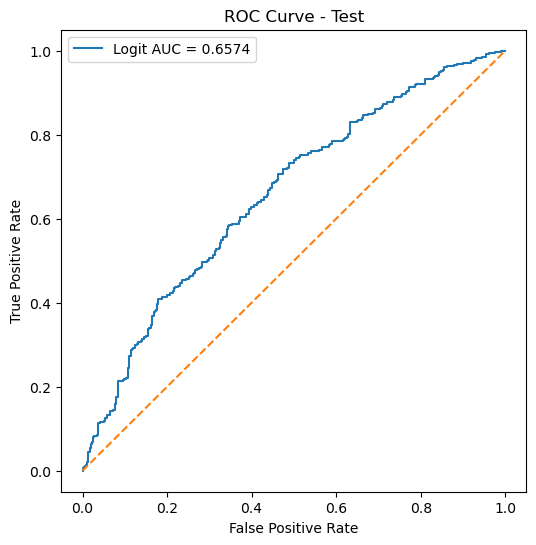

In [31]:
# -----------------------------
# ROC curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Logit AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test")
plt.legend()
plt.show()

In [32]:
# -----------------------------
# coefficient 확인
# -----------------------------
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": logit_model.coef_[0]
}).sort_values("coefficient", ascending=False)

display(coef_df)

,feature,coefficient
0,lineup_OPS_diff,1.445586
3,top5_OPS_diff,1.105114
2,lineup_SLG_diff,0.864172
1,lineup_OBP_diff,0.581414
4,top5_OBP_diff,0.431728
10,sp_HR9_diff,0.196297
9,sp_BB9_diff,0.091643
11,sp_KBB_diff,0.013020
8,sp_K9_diff,-0.008356
5,sp_ERA_diff,-0.087406


In [33]:
# -----------------------------
# test prediction dataframe
# -----------------------------
test_pred_df = test_df.copy()
test_pred_df["y_true"] = y_test.values
test_pred_df["y_pred"] = y_test_pred
test_pred_df["y_proba"] = y_test_proba

display(test_pred_df[["game_id", "game_date", "season", "y_true", "y_pred", "y_proba"]].head())

,game_id,game_date,season,y_true,y_pred,y_proba
1405,20250001,2025-03-22 05:00:00,2025,1,1,0.628122
1406,20250002,2025-03-22 05:00:00,2025,1,1,0.667345
1407,20250003,2025-03-22 05:00:00,2025,1,1,0.539803
1408,20250004,2025-03-22 05:00:00,2025,0,0,0.294584
1409,20250005,2025-03-22 05:00:00,2025,1,1,0.611709


#### Lift

In [34]:
def calculate_lift_table(y_true, y_proba, n_bins=10):
    """
    예측 확률 기준으로 내림차순 정렬 후
    decile별 lift 계산
    """
    lift_df = pd.DataFrame({
        "y_true": y_true,
        "y_proba": y_proba
    }).sort_values("y_proba", ascending=False).reset_index(drop=True)

    # decile bin
    lift_df["bin"] = pd.qcut(
        lift_df.index + 1,
        q=n_bins,
        labels=False
    ) + 1

    overall_rate = lift_df["y_true"].mean()

    summary = (
        lift_df.groupby("bin")
        .agg(
            n=("y_true", "size"),
            actual_win_rate=("y_true", "mean"),
            avg_proba=("y_proba", "mean")
        )
        .reset_index()
    )

    summary["lift"] = summary["actual_win_rate"] / overall_rate
    return summary, lift_df

In [35]:
lift_table, lift_raw = calculate_lift_table(y_test, y_test_proba, n_bins=10)

print("=== Lift Table ===")
display(lift_table)

=== Lift Table ===


,bin,n,actual_win_rate,avg_proba,lift
0,1,71,0.676056,0.745279,1.361716
1,2,71,0.746479,0.645426,1.503561
2,3,71,0.633803,0.591899,1.276609
3,4,71,0.436620,0.554377,0.879441
4,5,71,0.535211,0.515086,1.078025
5,6,70,0.542857,0.483712,1.093425
6,7,71,0.323944,0.453282,0.652489
7,8,71,0.464789,0.413649,0.936180
8,9,71,0.366197,0.363759,0.737596
9,10,71,0.239437,0.269701,0.482274


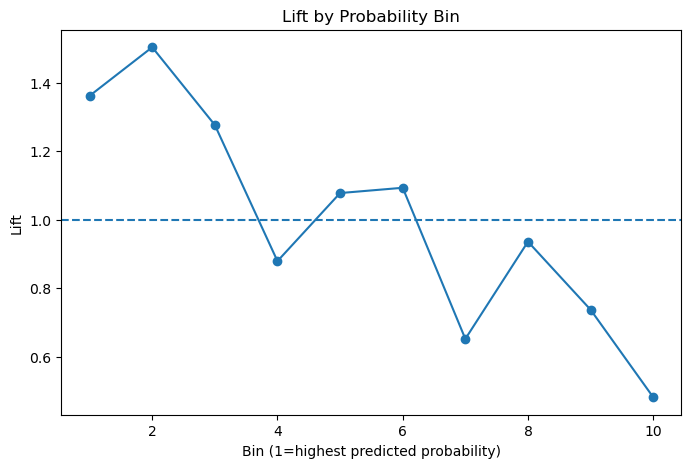

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(lift_table["bin"], lift_table["lift"], marker="o")
plt.axhline(y=1.0, linestyle="--")
plt.xlabel("Bin (1=highest predicted probability)")
plt.ylabel("Lift")
plt.title("Lift by Probability Bin")
plt.show()

In [37]:
# -----------------------------
# 상위 확률 경기 점검
# -----------------------------
top_test_pred_df = test_pred_df.sort_values("y_proba", ascending=False).copy()

print("=== Top 20 highest probability games ===")
display(
    top_test_pred_df[
        ["game_id", "game_date", "y_true", "y_pred", "y_proba"]
    ].head(20)
)

=== Top 20 highest probability games ===


,game_id,game_date,y_true,y_pred,y_proba
1514,20250127,2025-04-20 05:00:00,1,1,0.999809
1517,20250130,2025-04-20 05:00:00,1,1,0.853660
2111,20250981,2025-10-01 09:30:00,0,1,0.847279
2059,20250972,2025-09-15 09:30:00,1,1,0.829381
1447,20250050,2025-04-02 09:30:00,0,1,0.829314
2010,20250666,2025-08-30 09:00:00,1,1,0.824290
1732,20250352,2025-06-12 09:30:00,0,1,0.822140
1986,20250642,2025-08-24 09:00:00,1,1,0.805386
2022,20250861,2025-09-02 09:30:00,0,1,0.802933
1890,20250537,2025-07-31 09:30:00,1,1,0.801669


In [38]:
def evaluate_thresholds(y_true, y_proba, thresholds=np.arange(0.5, 0.95, 0.05)):
    rows = []

    for th in thresholds:
        mask = y_proba >= th
        n_selected = mask.sum()

        if n_selected == 0:
            rows.append({
                "threshold": th,
                "n_selected": 0,
                "accuracy": np.nan,
                "actual_win_rate": np.nan
            })
            continue

        y_sel = y_true[mask]
        pred_sel = (y_proba[mask] >= th).astype(int)

        rows.append({
            "threshold": th,
            "n_selected": n_selected,
            "accuracy": (y_sel == pred_sel).mean(),
            "actual_win_rate": y_sel.mean()
        })

    return pd.DataFrame(rows)

In [39]:
threshold_eval_df = evaluate_thresholds(y_test.values, y_test_proba)
display(threshold_eval_df)

,threshold,n_selected,accuracy,actual_win_rate
0,0.50,352,0.607955,0.607955
1,0.55,254,0.641732,0.641732
2,0.60,159,0.685535,0.685535
3,0.65,98,0.693878,0.693878
4,0.70,58,0.706897,0.706897
5,0.75,26,0.730769,0.730769
6,0.80,10,0.600000,0.600000
7,0.85,2,1.000000,1.000000
8,0.90,1,1.000000,1.000000


### XGBoost, LightGBM 모델도 확장 고려.